# Notebook 6 — Red Neuronal Artificial (ANN)

In [1]:
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    import glob
    paths = glob.glob('/content/drive/**/emg-classification-knn-svm-ann', recursive=True)
    pc = [p for p in paths if 'Othercomputers' in p or 'Ordenadores' in p]
    PROJECT_PATH = sorted(pc or paths, key=len)[0] if paths else '/content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann'
    os.chdir(PROJECT_PATH)
    sys.path.insert(0, PROJECT_PATH)
except:
    if 'notebooks' in os.getcwd(): os.chdir('..')
    sys.path.insert(0, os.getcwd())

print('CWD:', os.getcwd())


Mounted at /content/drive
CWD: /content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann


In [2]:
from src.config import Config
from src.evaluation import get_confusion_matrix, compute_metrics
from src.visualization import plot_confusion_matrix
from sklearn.metrics import classification_report

features_dir = Config.PROCESSED_DIR / 'features'
data = np.load(features_dir / 'emg_features_base.npz', allow_pickle=True)
meta = np.load(features_dir / 'emg_metadata_base.npz', allow_pickle=True)

X      = data['X']
y      = data['y']
splits = meta['splits']

train_idx = np.where(splits == 'train_samples')[0]
test_idx  = np.where(splits == 'test_samples')[0]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

class_names = sorted(np.unique(y).tolist())
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Clases:', class_names)


Train: (12500, 48)  |  Test: (6250, 48)
Clases: ['fist', 'open', 'pinch', 'waveIn', 'waveOut']


In [3]:
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler, LabelEncoder

print(f'TensorFlow: {tf.__version__}')

scaler  = StandardScaler()
encoder = LabelEncoder()

X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
y_train_e = encoder.fit_transform(y_train)
y_test_e  = encoder.transform(y_test)

n_classes = len(class_names)
n_feats   = X_train_s.shape[1]
print(f'Input dim: {n_feats}  |  Classes: {n_classes}')


TensorFlow: 2.19.0
Input dim: 48  |  Classes: 5


In [4]:
model = Sequential([
    Input(shape=(n_feats,)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax'),
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,853 (58.02 KB)

 Trainable params: 14,853 (58.02 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_s, y_train_e,
    epochs=100, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7234 - loss: 0.7460 - val_accuracy: 0.7800 - val_loss: 0.5730
Epoch 2/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7931 - loss: 0.5545 - val_accuracy: 0.7920 - val_loss: 0.5732
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8107 - loss: 0.5091 - val_accuracy: 0.7848 - val_loss: 0.5624
Epoch 4/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8255 - loss: 0.4688 - val_accuracy: 0.7968 - val_loss: 0.5555
Epoch 5/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8364 - loss: 0.4411 - val_accuracy: 0.8040 - val_loss: 0.5623
Epoch 6/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8403 - loss: 0.4376 - val_accuracy: 0.8184 - val_loss: 0.5293
Epoch 7/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8477 - loss: 0.4101 - val_accuracy: 0.8144 - val_loss: 0.5103
Epoch 8/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8550 - loss: 0.3983 - val_acc

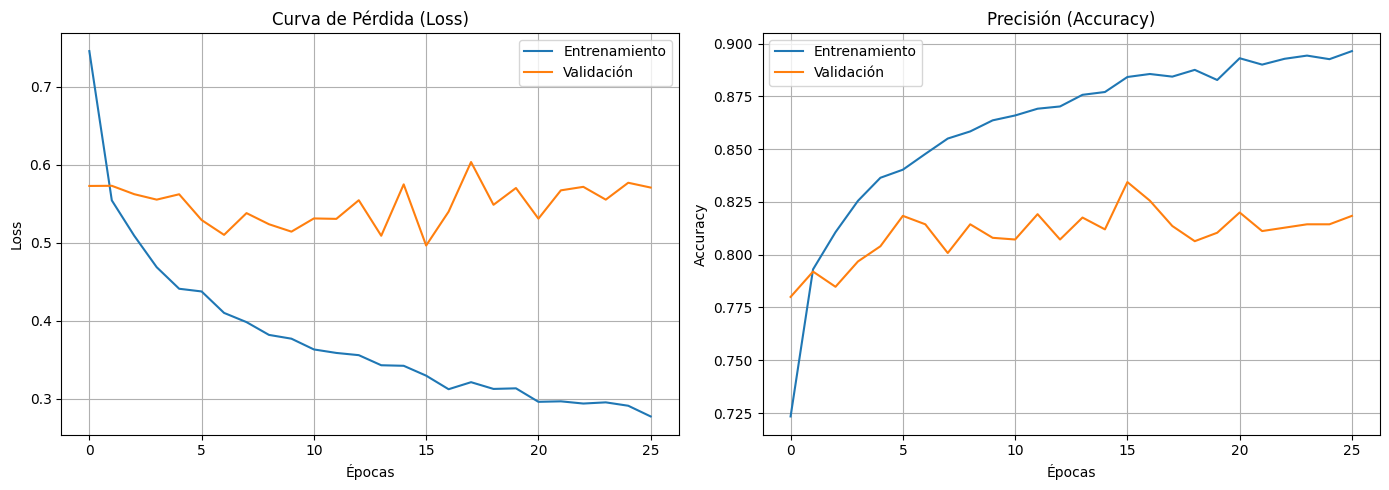

In [6]:
# Curvas de aprendizaje
from src.visualization import plot_learning_curve_keras
plot_learning_curve_keras(history)


196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Reporte ANN:

              precision    recall  f1-score   support

        fist       0.89      0.93      0.91      1250
        open       0.81      0.88      0.84      1250
       pinch       0.90      0.84      0.87      1250
      waveIn       0.90      0.88      0.89      1250
     waveOut       0.95      0.90      0.93      1250

    accuracy                           0.89      6250
   macro avg       0.89      0.89      0.89      6250
weighted avg       0.89      0.89      0.89      6250



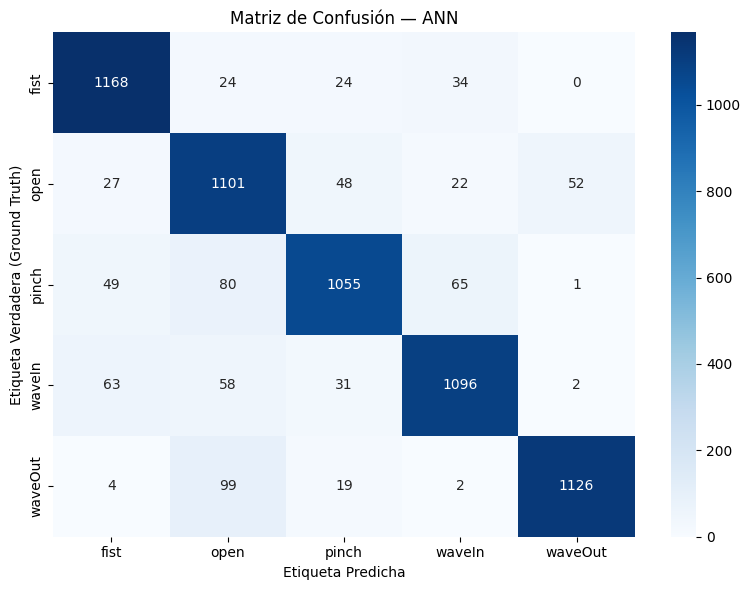

In [7]:
y_pred_enc = np.argmax(model.predict(X_test_s), axis=1)
y_pred     = encoder.inverse_transform(y_pred_enc)

print('Reporte ANN:\n')
print(classification_report(y_test, y_pred, target_names=class_names))

cm = get_confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, class_names, title='Matriz de Confusión — ANN')


In [8]:
models_dir = Config.PROCESSED_DIR / 'models'
os.makedirs(models_dir, exist_ok=True)
model.save(models_dir / 'best_ann_model.h5')
joblib.dump(scaler,  models_dir / 'ann_scaler.pkl')
joblib.dump(encoder, models_dir / 'ann_encoder.pkl')
print(f'Modelos guardados en {models_dir}')


Modelos guardados en /content/drive/Othercomputers/My PC/emg-classification-knn-svm-ann/data/processed/models
